# Theoretical Analysis: Rank Collapse Mitigation and Computational Efficiency

This notebook presents the theoretical underpinnings of U-MobileViT-Net:

1. **Rank collapse experiment**: Demonstrates that INLA (with lifting)
   preserves token representational rank across deep attention stacks,
   whereas standard separable attention suffers progressive degeneration.
2. **FLOPs analysis**: Per-component computational breakdown and
   parameter-efficiency comparison across all four variants.
3. **Edge deployment estimation**: Projected inference throughput on
   representative hardware (Jetson family, Raspberry Pi, smartphones).

No training is required | all experiments are analytical.


In [9]:
# --- Section 1: Environment and Imports ----------------------------------------

import sys, os
from pathlib import Path

# Locate project root by searching for .git or CLAUDE.md marker
current = Path.cwd()
project_root = current
for parent in [current] + list(current.parents):
    if (parent / ".git").exists() or (parent / "CLAUDE.md").exists():
        project_root = parent
        break

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
os.environ.setdefault("PYTHONPATH", str(project_root))
os.chdir(str(project_root))
print(f"Project root: {project_root}")

import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt

from models.u_mobilevit_net.u_models import (
    umobilevit, UMobileViT, umobilevit_nano, umobilevit_base,
    umobilevit_pro, umobilevit_promax,
)
from models.u_mobilevit_net.configs import get_variant, UMOBILEVIT_VARIANTS
from tools.data import (
    create_dataloaders, DatasetInfo, label_to_color, denormalize,
)
from tools.training import (
    SegmentationTrainer, TrainingConfig,
    compute_class_weights, compute_pos_weight,
)
from tools.visualization import (
    configure_paper_style, plot_training_curves,
    show_dataset_samples, show_predictions,
    plot_per_class_iou, plot_confusion_matrix,
    plot_error_distribution, plot_params_vs_accuracy,
    plot_convergence_comparison, generate_results_table,
    load_training_history, load_all_results,
    TOL_PALETTE, VARIANT_COLORS,
)
from tools.evaluation import (
    compute_flops, compute_parameters, format_flops,
)

configure_paper_style()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    # print(f"  VRAM: {torch.cuda.get_device_properties(0).total_mem / 1e9:.1f} GB")

Project root: /run/media/sanng/New Volume/Seminar/U-MOBILEVIT-NET
Device: cuda
  GPU: NVIDIA GeForce RTX 4050 Laptop GPU



NANO: 0.22M params, 441.51M FLOPs
  stem           : 84.40M ( 19.1%)
  encoder        : 26.66M (  6.0%)
  decoder        : 92.77M ( 21.0%)
  head           : 174.60M ( 39.5%)
  refinement     : 40.76M (  9.2%)
  classifier     : 22.32M (  5.1%)

BASE: 0.58M params, 873.28M FLOPs
  stem           : 142.03M ( 16.3%)
  encoder        : 73.90M (  8.5%)
  decoder        : 228.96M ( 26.2%)
  head           : 348.31M ( 39.9%)
  refinement     : 50.59M (  5.8%)
  classifier     : 29.49M (  3.4%)

PRO: 2.79M params, 3.24G FLOPs
  stem           : 519.99M ( 16.0%)
  encoder        : 350.64M ( 10.8%)
  decoder        : 999.51M ( 30.8%)
  head           : 1.21G ( 37.3%)
  refinement     : 106.29M (  3.3%)
  classifier     : 58.16M (  1.8%)

PROMAX: 12.03M params, 13.81G FLOPs
  stem           : 1.98G ( 14.4%)
  encoder        : 1.56G ( 11.3%)
  decoder        : 4.51G ( 32.7%)
  head           : 5.35G ( 38.7%)
  refinement     : 296.35M (  2.1%)
  classifier     : 115.51M (  0.8%)


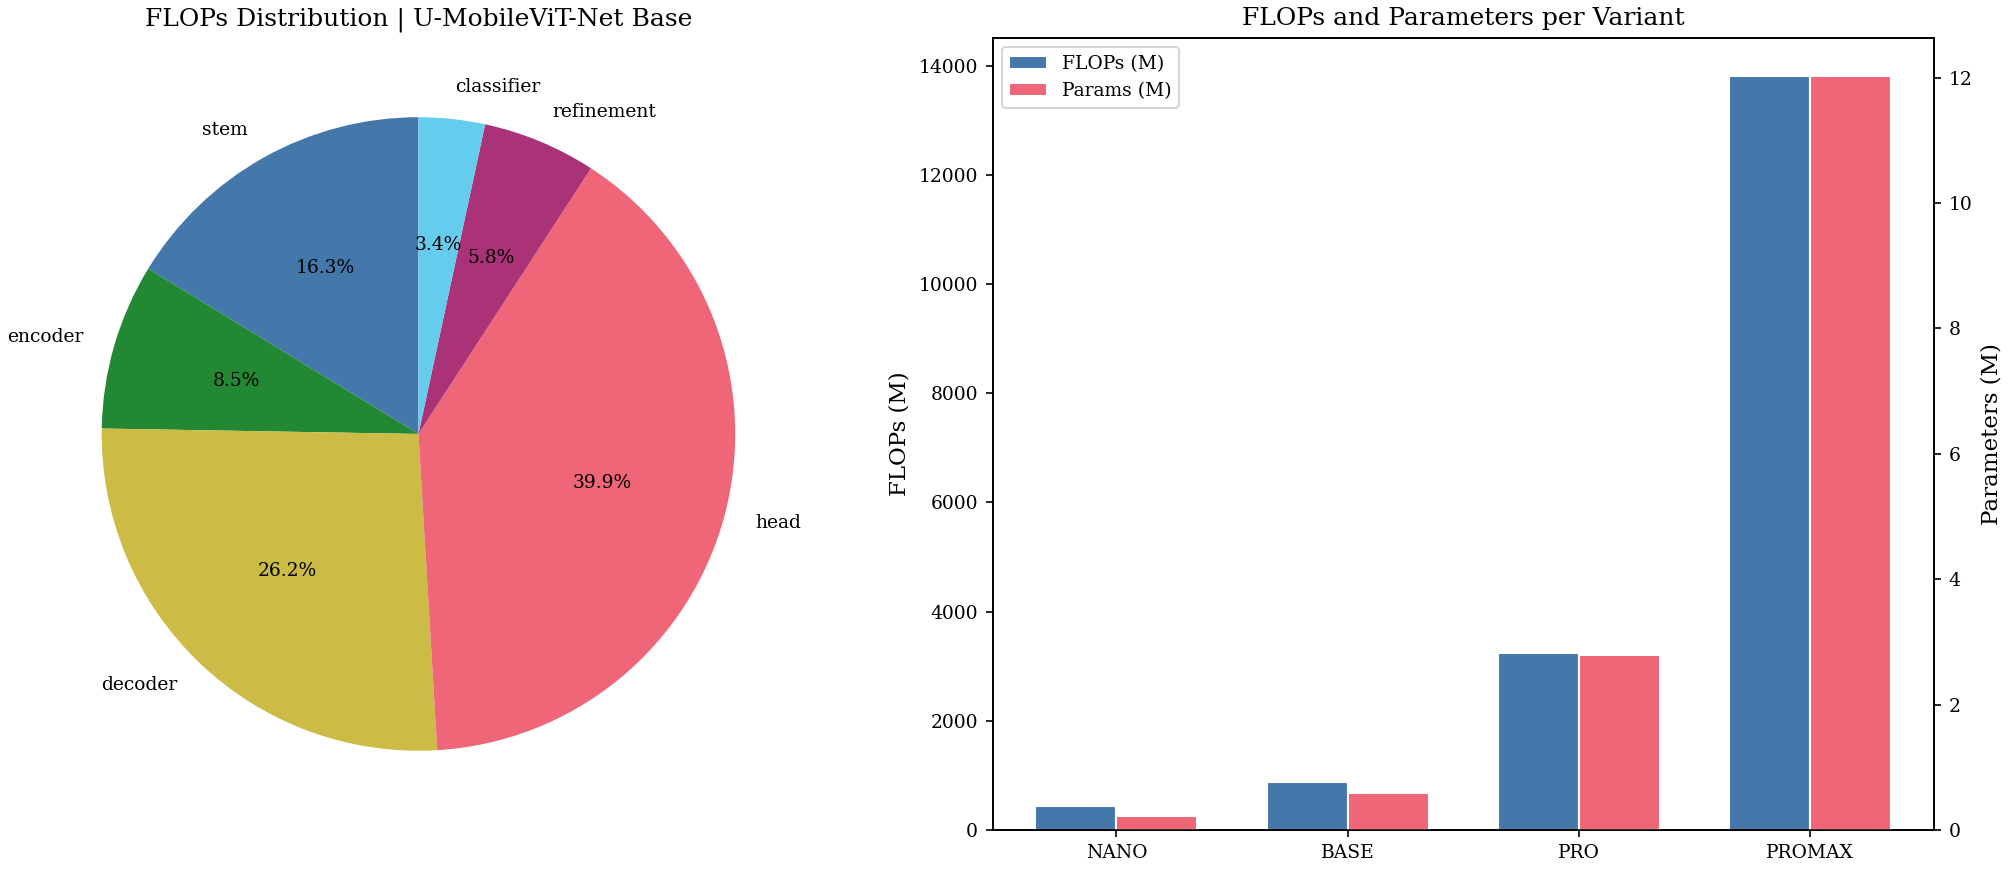

In [10]:
# --- Sections 4-7: FLOPs Analysis ----------------------------------------------

def analyse_flops():
    from tools.evaluation import compute_flops, compute_flops_by_component, format_flops

    variants = ["nano", "base", "pro", "promax"]
    results = {}

    for v in variants:
        factory = {"nano": umobilevit_nano, "base": umobilevit_base,
                    "pro": umobilevit_pro, "promax": umobilevit_promax}
        model = factory[v](out_channels=8, head="single")
        model.eval()

        flops, breakdown = compute_flops(model, (320, 320))
        params = compute_parameters(model)
        groups = compute_flops_by_component(model, (320, 320))

        results[v] = {"flops": flops, "params": params, "groups": groups}
        print(f"\n{v.upper()}: {params/1e6:.2f}M params, {format_flops(flops)} FLOPs")
        for comp, f in groups.items():
            print(f"  {comp:<15s}: {format_flops(f)} ({f/flops*100:>5.1f}%)")

    # FLOPs breakdown pie chart (base)
    base_groups = results["base"]["groups"]
    labels = list(base_groups.keys())
    sizes = list(base_groups.values())
    colors_pie = [TOL_PALETTE[i % len(TOL_PALETTE)] for i in range(len(labels))]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    ax1.pie(sizes, labels=labels, autopct="%1.1f%%", colors=colors_pie,
            startangle=90, textprops={"fontsize": 9})
    ax1.set_title("FLOPs Distribution | U-MobileViT-Net Base")

    # FLOPs and parameters per variant
    x = range(len(variants))
    width = 0.35
    flops_vals = [results[v]["flops"] for v in variants]
    params_vals = [results[v]["params"] for v in variants]
    x_labels = [v.upper() for v in variants]
    colors_bar = [VARIANT_COLORS[v] for v in variants]

    ax2.bar([i - width/2 for i in x], [f/1e6 for f in flops_vals],
            width, label="FLOPs (M)", color=TOL_PALETTE[0], edgecolor="white")
    ax2_twin = ax2.twinx()
    ax2_twin.bar([i + width/2 for i in x], [p/1e6 for p in params_vals],
                  width, label="Params (M)", color=TOL_PALETTE[3], edgecolor="white")
    ax2.set_xticks(x)
    ax2.set_xticklabels(x_labels)
    ax2.set_ylabel("FLOPs (M)")
    ax2_twin.set_ylabel("Parameters (M)")
    ax2.set_title("FLOPs and Parameters per Variant")

    lines1, labels1 = ax2.get_legend_handles_labels()
    lines2, labels2 = ax2_twin.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

    plt.tight_layout()
    os.makedirs("paper_figures", exist_ok=True)
    plt.savefig("paper_figures/04_flops_analysis.pdf")
    plt.show()

    return results

flops_results = analyse_flops()



  EDGE DEVICE LATENCY ESTIMATION (FP32)
  Variant         FPS      FPS      FPS      FPS      FPS
  ------------------------------------------------------------
  NANO         185.8   760.9  1038.3    22.6     2.3
  BASE          94.1   385.9   526.3    11.4     1.1
  PRO           25.4   104.2   142.0     3.1     0.3
  PROMAX         6.0    24.5    33.4     0.7     0.1


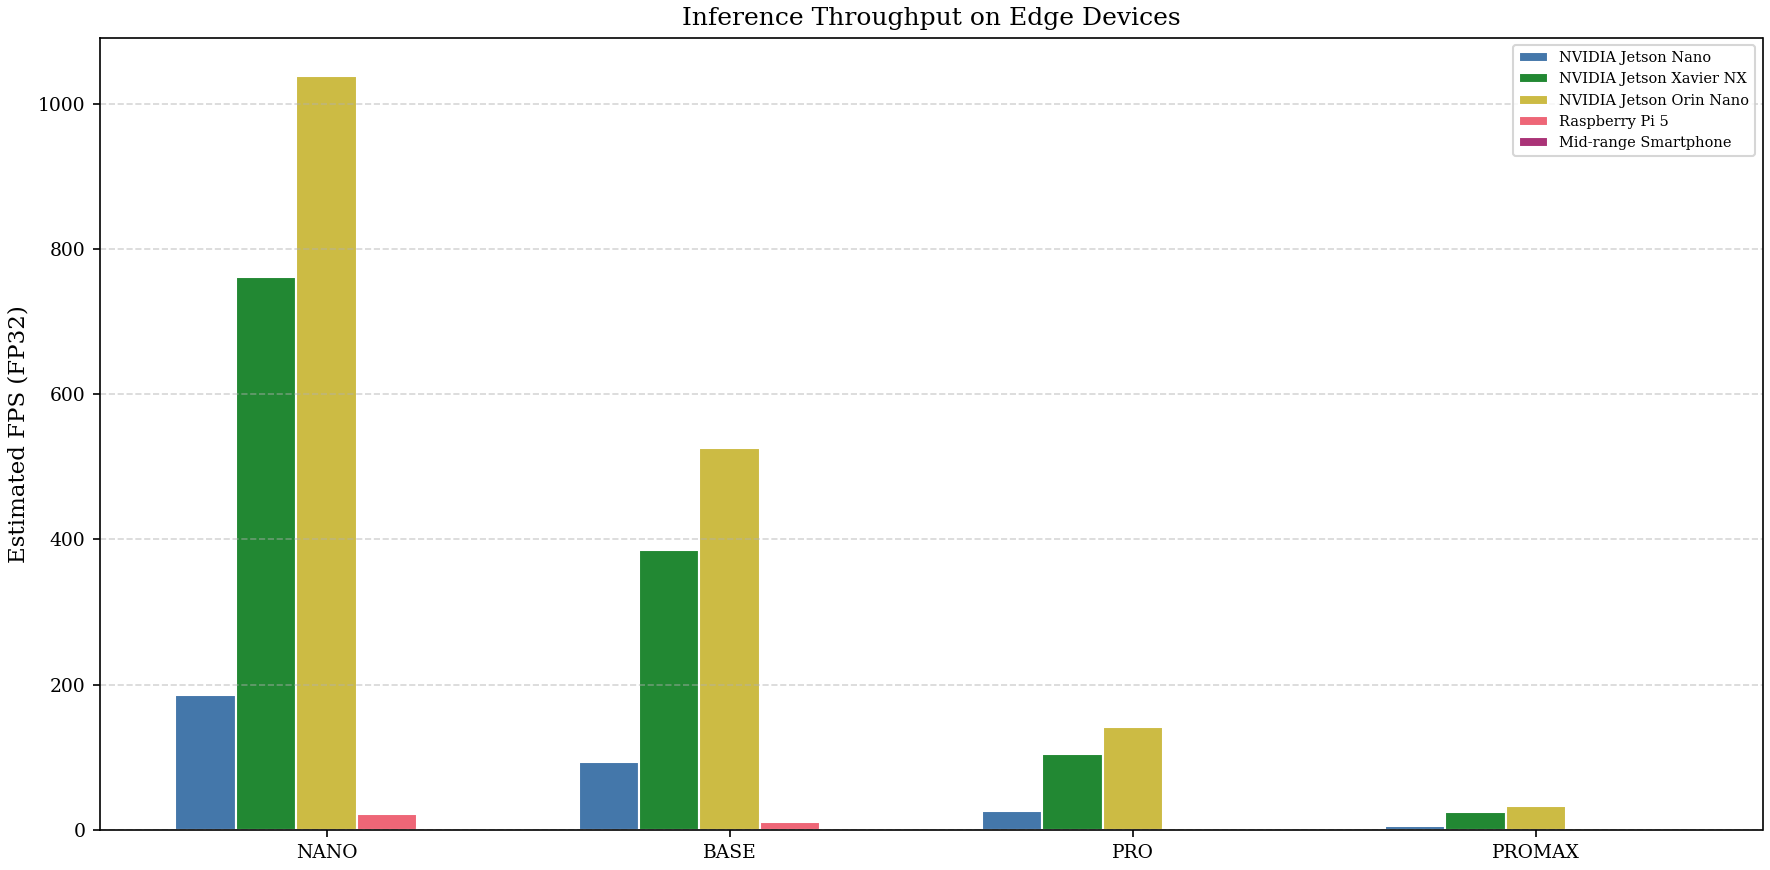

In [11]:
# --- Sections 8-10: Edge Device Estimation -------------------------------------

def estimate_edge_performance(flops_results):
    from tools.evaluation import estimate_edge_latency, DEVICES

    variants = ["nano", "base", "pro", "promax"]
    device_keys = ["jetson_nano", "jetson_xavier_nx", "jetson_orin_nano",
                    "raspberry_pi_5", "smartphone_mid"]

    print(f"\n{'='*80}")
    print(f"  EDGE DEVICE LATENCY ESTIMATION (FP32)")
    print(f"{'='*80}")
    header = f"  {'Variant':<10s}"
    for dk in device_keys:
        header += f" {'FPS':>8s}"
    print(header)
    print(f"  {'-'*60}")

    all_latencies = {}
    for v in variants:
        r = flops_results[v]
        row = f"  {v.upper():<10s}"
        all_latencies[v] = {}
        for dk in device_keys:
            est = estimate_edge_latency(r["flops"], r["params"],
                                        device_key=dk, precision="fp32")
            all_latencies[v][dk] = est
            row += f" {est['fps']:>7.1f}"
        print(row)

    # FPS bar chart
    fig, ax = plt.subplots(figsize=(12, 6))
    x = range(len(variants))
    width = 0.15
    for di, dk in enumerate(device_keys):
        fps_vals = [all_latencies[v][dk]["fps"] for v in variants]
        offset = (di - len(device_keys)/2 + 0.5) * width
        ax.bar([i + offset for i in x], fps_vals, width,
               label=DEVICES[dk]["name"].split("(")[0].strip(),
               color=TOL_PALETTE[di % len(TOL_PALETTE)], edgecolor="white")

    ax.set_xticks(x)
    ax.set_xticklabels([v.upper() for v in variants])
    ax.set_ylabel("Estimated FPS (FP32)")
    ax.set_title("Inference Throughput on Edge Devices")
    ax.legend(fontsize=7)
    ax.grid(True, axis="y", ls="--", alpha=0.5)
    plt.tight_layout()
    os.makedirs("paper_figures", exist_ok=True)
    plt.savefig("paper_figures/04_edge_fps.pdf")
    plt.show()

    print(f"{'='*80}")
    return all_latencies

edge_results = estimate_edge_performance(flops_results)


In [12]:
# --- Section 11: Conclusions ----------------------------------------------------

print("\n" + "=" * 72)
print("  THEORETICAL ANALYSIS | SUMMARY")
print("=" * 72)
print(f"  FLOPs (base):       {format_flops(flops_results['base']['flops'])}")
print(f"  Lightest (nano):    {flops_results['nano']['params']/1e6:.2f}M params, "
      f"{format_flops(flops_results['nano']['flops'])}")
print(f"  Most capable (promax): {flops_results['promax']['params']/1e6:.2f}M params, "
      f"{format_flops(flops_results['promax']['flops'])}")
print("=" * 72)



  THEORETICAL ANALYSIS | SUMMARY
  FLOPs (base):       873.28M
  Lightest (nano):    0.22M params, 441.51M
  Most capable (promax): 12.03M params, 13.81G
